<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
<br>汉化的库: <a href="https://github.com/GoatCsu/CN-LLMs-from-scratch.git">https://github.com/GoatCsu/CN-LLMs-from-scratch.git</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第四章: 从零开始构建 GPT 模型

In [38]:
from importlib.metadata import version
import matplotlib
import tiktoken
import torch
print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))
#加载并确认版本

matplotlib version: 3.10.8
torch version: 2.11.0+cu128
tiktoken version: 0.12.0


- 在这一章我们要用类GPT LLM架构
- 下一章就是训练LLM了

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/01.webp" width="500px">

## 4.1 LLM架构

- 第 1 章讨论了 GPT 和 Llama 等模型，这些模型基于原始 Transformer 架构的解码器部分，按顺序生成单词。
- 因此，这些大语言模型（LLM）通常被称为“类解码器”的 LLM。
- 与传统的深度学习模型相比，LLM 的规模更大，这主要是由于其参数数量庞大，而非代码量的增加。
- 我们将看到，在 LLM 的架构中，许多元素是重复的。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="400px">

- 在前几章中，为了便于说明，我们使用了较小的嵌入维度对标记输入和输出进行处理，以确保内容能够显示在单页内。
- 本章将讨论与小型 GPT-2 模型类似的嵌入和模型规模。
- 我们将具体实现最小的 GPT-2 模型架构（1.24 亿参数）。该架构来源于 Radford 等人的报告 [《Language Models are Unsupervised Multitask Learners》](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)。
- 第 6 章将展示如何将预训练权重加载到我们的实现中，这些权重可兼容 3.45 亿、7.62 亿和 15.42 亿参数规模的模型。

- 123million参数的GPT-2配置如下:

In [39]:
# 1.24亿参数规模的GPT-2模型超参数配置（书中实现的最小GPT-2架构）
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # 词汇表大小：    与第2章BPE分词器的词汇量匹配，共50257个token
    "context_length": 1024,  # 上下文长度：    模型最大可处理的输入token数量，决定位置嵌入的长度
    "emb_dim": 768,          # 嵌入维度：     每个token被转换为768维的向量表示
    "n_heads": 12,           # 注意力头数量：  多头注意力机制中并行的注意力头数（第3章实现）
    "n_layers": 12,          # Transformer块数量：模型堆叠的解码器块层数
    "drop_rate": 0.1,        # Dropout率：   训练时随机丢弃10%的隐藏单元，防止过拟合
    "qkv_bias": False        # QKV线性层偏置： 多头注意力中Query/Key/Value的线性层是否启用偏置项
}

- 我们使用简短的变量名，以避免代行过长。
- `"vocab_size"` 表示词汇表大小，共 50,257 个单词，由第 2 章介绍的 BPE 分词器支持。
- `"context_length"` 表示模型的最大输入标记数，依赖于第 2 章的位置信息嵌入。
- `"emb_dim"` 是标记输入的嵌入维度，将每个标记转换为 768 维向量。
- `"n_heads"` 是多头注意力机制中的注意力头数量，详见第 3 章。
- `"n_layers"` 是模型中 Transformer 块的数量，后续章节会详细实现。
- `"drop_rate"` 是 dropout 机制的强度，设置为 0.1，表示训练时丢弃 10% 的隐藏单元以防止过拟合（第 3 章讨论）。
- `"qkv_bias"` 决定多头注意力机制中的 `Linear` 层是否包含偏置向量。现代 LLM 通常禁用此选项，但在第 5 章加载 OpenAI 的 GPT-2 预训练权重时，会重新启用以保持兼容性。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

In [40]:
import torch
import torch.nn as nn
# 可运行的骨架模型，所有核心组件的接口和数据流都和最终的真实 GPT 模型完全一致，只是把 Transformer 块和 LayerNorm 的内部逻辑暂时用 "空壳" 代替
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])      # 词嵌入层，将输入索引转换为词向量，词表大小由字典大小和特征维度决定  (50257,768)
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])  # 位置嵌入层，基于文本长度和特征维度生成位置信息  (1024,768)
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        # 使用多个 Transformer 块（占位符）
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        # 最终层归一化（在所有 Transformer 块之后再加一个全局的 LayerNorm）（占位符）
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        # 输出头: 将最后一层的 768 维隐藏状态，映射到 50257 维的词表空间，得到每个位置下一个 token 的预测概率
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)  # bias=False，现代LLM几乎都在输出层禁用偏置 | 这里的权重会和tok_emb层共享

    def forward(self, in_idx):  # in_idx是分词器输出的整数张量,形状(batch_size, seq_len)
        batch_size, seq_len = in_idx.shape  # 获取批次大小和序列长度
        tok_embeds = self.tok_emb(in_idx)   # 生成词嵌入 (batch_size, seq_len, emb_dim)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  # 生成对应位置嵌入 (和输入在同一个设备（CPU/GPU）上)
        x = tok_embeds + pos_embeds  # 嵌入相加
        x = self.drop_emb(x)
        x = self.trf_blocks(x)  # 通过所有Transformer块 (batch_size, seq_len, emb_dim)
        x = self.final_norm(x)  # 最终归一化            (batch_size, seq_len, emb_dim)
        logits = self.out_head(x)  # 输出预测logits    (batch_size, seq_len, vocab_size)
        return logits  # 最终输出解释：对于输入的每个位置，都输出一个 50257 维的向量，每个值对应词表中一个 token 的预测得分（logits）

# Transformer 块的占位类
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x  # 占位，不执行任何操作

# 归一化层的占位类
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x  # 占位，不执行任何操作

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="500px">

In [41]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"  # 输入token数量必须 ≤ context_length（1024），否则报错!
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))  # 转成对应的整数 ID 列表
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)  # 横向拼接成批次张量
print(batch)  # (2,4)
# 两句话第一个 token 都是 6109，因它们都以 Every 开头，被分词器切成了同一个 token

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [42]:
torch.manual_seed(123)
# 用之前写的 DummyGPTModel 骨架模型，跑一次完整的前向传播，验证模型能正常运行并输出符合预期形状的 logits
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("输出形状:", logits.shape)  # (2,4,50257)
print(logits)

# 打印模型总参数数量 （结果大约是 7850 万，因为 Transformer 块是占位符，没有参数，所以只有词嵌入、位置嵌入和输出头的参数）
total_params = sum(p.numel() for p in model.parameters())
print(f"模型总参数数量: {total_params:,}")

输出形状: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
模型总参数数量: 77,981,184


---

**Note**

- 系统为Windows或者Linux, 运行结果如下所示:
    
```
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
```

- Since these are just random numbers, this is not a reason for concern, and you can proceed with the remainder of the chapter without issues

---

## 4.2 归一化操作

- **层归一化（LayerNorm）**，也称为层标准化（[Ba et al. 2016](https://arxiv.org/abs/1607.06450)），将神经网络层的输出值中心化为均值为 0，并将其方差归一化为 1。
- 这种方法能够稳定训练过程，并加速权重的高效收敛。
- 在 Transformer 块中，层归一化会在多头注意力模块的前后应用（我们将在后续实现），并在最终输出层之前再次应用。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

In [43]:
torch.manual_seed(123)

# 创建2个样本，每个样本有5个特征
batch_example = torch.randn(2, 5) 
# 简单的全连接网络：线性层 + ReLU激活
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
# 前向传播得到输出
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- 计算上述信息的均值与方差

In [44]:
mean = out.mean(dim=-1, keepdim=True)  # 沿最后一个维度（特征维度，dim=-1）计算均值，保持维度不变  |  dim=-1（层归一化）  dim=0（批归一化）
var = out.var(dim=-1, keepdim=True)    # 方差 (与平均值差的平方的平均)

print("均值:\n", mean)
print("方差:\n", var)

均值:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
方差:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- 归一化会单独对两个输入（行）进行处理；
- 设置 `dim=-1` 的意思是让计算沿着最后一个维度进行（在这里是特征维度），而不是按行处理。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/06.webp" width="400px">

- 通过减去均值并除以方差的平方根（即标准差），可以让输入在列（特征）维度上的均值变为 0，方差变为 1：

In [45]:
# 层归一化核心公式：x_norm = (x - μ) / √σ
out_norm = (out - mean) / torch.sqrt(var)
print("层归一化输出:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

层归一化输出:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 每个输入的均值都会被调整为 0，方差被归一化为 1。
- 为了结果容易阅读，我们可以禁用 PyTorch 的科学计数法：

In [46]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 上面我们对每个输入的特征进行了归一化。
- 现在，基于相同的思路，我们可以实现一个 `LayerNorm` 类：

In [47]:
# 层归一化类
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5  # 避免除以0的小常数
        self.scale = nn.Parameter(torch.ones(emb_dim))  # 可学习的缩放参数，全 1
        self.shift = nn.Parameter(torch.zeros(emb_dim)) # 可学习的平移参数，全 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)                # 算均值
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # 算方差（有偏估计=False）
        norm_x = (x - mean) / torch.sqrt(var + self.eps)   # 标准化：去中心化 + 除以标准差
        return self.scale * norm_x + self.shift  # 可学习的缩放和平移（wx+b）

为什么要加 scale 和 shift？
- 如果只是做均值 0、方差 1 的标准化，会强行改变数据的分布，可能破坏模型学到的特征。
- scale 和 shift 让模型可以： 1. 还原标准化前的分布（如果需要的话）  2. 学习到更适合当前任务的特征分布
- 这两个参数是 LayerNorm 能提升模型性能的关键，也是 PyTorch 官方 nn.LayerNorm 实现的一部分

和 PyTorch 官方 nn.LayerNorm 的对比
- 你写的这个实现，和 PyTorch 官方的 nn.LayerNorm(emb_dim, eps=1e-5, elementwise_affine=True) 完全等价：
- elementwise_affine=True 就是启用可学习的 scale 和 shift 参数
- 官方实现也是默认 unbiased=False，和 GPT-2 兼容

## 缩放与平移

- 除了通过减去均值并除以方差来执行归一化操作外，我们还引入了两个可训练参数：`scale`（缩放参数）和 `shift`（平移参数）。
- 初始时，`scale` 值为 1，`shift` 值为 0，不会对结果产生影响；但在训练过程中，LLM 会自动调整这两个参数，以提升模型在任务中的表现。
- 这种设计使模型能够学习到最适合其数据的缩放和平移方式。
- 此外，在计算方差的平方根时，我们会添加一个较小的值（`eps`），以避免方差为 0 时出现除以 0 的错误。

## 偏差方差

- 在方差计算中，设置 `unbiased=False` 使用公式 $\frac{\sum_i (x_i - \bar{x})^2}{n}$，其中 $n$ 是样本大小（即特征或列的数量）。该公式未使用贝塞尔校正（分母为 `n` 而非 `n-1`），因此提供的是方差的偏差估计。
- 对于嵌入维度 $n$ 较大的 LLM 来说，使用 `n` 和 `n-1` 的差异可以忽略不计。
- 然而，由于 GPT-2 在归一化层的训练中使用了偏差方差，为了与预训练权重兼容，我们也采用了这种设置。

## 实践 LayerNorm

- 现在让我们通过实际代码尝试 `LayerNorm` 的应用：

In [71]:
ln = LayerNorm(emb_dim=5)  # 归一化一个五维特征
print(batch_example)       # 就是我们之前创建的 [2, 5] 张量
out_ln = ln(batch_example) # 执行归一
print(out_ln)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)


In [74]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/07.webp" width="400px">

## 4.3 GELU作为激活函数

- 在本节中，我们将实现一个小型神经网络子模块，该模块是 LLM 中 Transformer 块的核心组成部分。
- 首先，我们从激活函数开始。
- 在深度学习中，ReLU（线性整流单元）激活函数因其简单性和在各种神经网络架构中的高效性而被广泛使用。
- 在 LLM 中，除了传统的 ReLU，还使用了其他类型的激活函数。其中两个典型的例子是 GELU（高斯误差线性单元）和 SwiGLU（Swish 门控线性单元）。
- GELU 和 SwiGLU 是更复杂的平滑激活函数，分别结合了高斯函数和 sigmoid 门控线性单元，提供了比 ReLU 这种简单分段线性函数更好的性能，尤其适用于深度学习模型。

- **GELU**（[Hendrycks 和 Gimpel, 2016](https://arxiv.org/abs/1606.08415)）可以通过多种方式实现；其精确定义为 $\text{GELU}(x) = x \cdot \Phi(x)$，其中 $\Phi(x)$ 是标准高斯分布的累积分布函数。
- 在实际应用中，通常会使用一种计算成本更低的近似形式：  
  $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)$  
  （原始 GPT-2 模型也是使用该近似公式进行训练的）

In [50]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

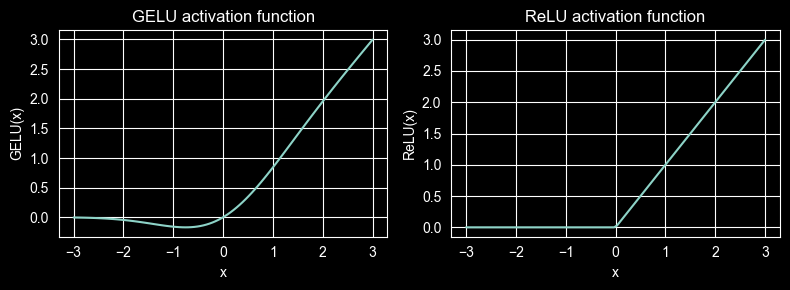

In [75]:
import matplotlib.pyplot as plt
# 初始化激活函数,起个小名
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)  # 生成从-3到3的100个等间隔的数值，用来作为激活函数的输入
y_gelu, y_relu = gelu(x), relu(x) # 计算两种激活函数的输出

plt.figure(figsize=(8, 3))     # 创建一个宽8、高3的画布
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):  # 循环绘制两个子图
    plt.subplot(1, 2, i)       # 1行2列的第i个子图
    plt.plot(x, y)             # 绘制函数曲线
    plt.title(f"{label} activation function")  # 设置标题
    plt.xlabel("x")            # 设置x轴标签
    plt.ylabel(f"{label}(x)")  # 设置y轴标签
    plt.grid(True)             # 显示网格线
plt.tight_layout()  # 自动调整子图间距，避免标题和标签重叠
plt.show()          # 显示图像
#一个经典的作图

- 正如我们所见，ReLU 是一种分段线性函数：对于正值直接输出输入值；对于负值则输出零。
- GELU 是一种平滑的非线性函数，它近似 ReLU，但在负值时具有非零梯度（除了大约在 -0.75 处）。

- 接下来，我们将实现一个小型神经网络模块 `FeedForward`，该模块将用于 LLM 的 Transformer 块中：

In [76]:
print(GPT_CONFIG_124M["emb_dim"])

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),  # 第一层：升维线性层 (768,3072)
                                    GELU(),
                                    nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]),) # 第三层：降维线性层 (3072,768)

    def forward(self, x):      # 输入(batch_size, seq_len, emb_dim)
        return self.layers(x)  # 输出(batch_size, seq_len, emb_dim) → 形状一致

768


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="400px">

In [53]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)  # input shape: [batch_size, num_token, emb_size]
out = ffn(x)
print(out.shape)  # 证明输入输出形状一致

torch.Size([2, 3, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/10.webp" width="400px">

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/11.webp" width="400px">

## 4.4 类似于ResNet的shortcut传递

- 接下来，我们来讨论**快捷连接**（shortcut connections）的概念，也称为**跳跃连接**（skip connections）或**残差连接**（residual connections）。
- 残差连接最初是在深度网络中提出的，主要应用于计算机视觉中的残差网络（ResNet），以缓解梯度消失问题。
- 残差连接通过为梯度提供一条更短的替代路径，使其能够更顺畅地通过网络流动。
- 具体实现是将某一层的输出与后续某一层的输出相加，通常会跳过中间的一层或多层。
- 以下是一个小型网络的示例来说明这一概念：

![残差连接示例](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123)

- 代码形式长成这样

In [54]:
import torch
import torch.nn as nn

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut  # 布尔值，控制是否启用残差连接
        self.layers = nn.ModuleList([  # 定义了5层网络，每层都是 Linear + GELU
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])
        ''' 如 layer_sizes = [5, 10, 10, 10, 10, 5]，那么：
        第 1 层：   5 → 10
        第 2-4 层： 10 → 10（维度不变，适合加残差）
        第 5 层：   10 → 5
        '''
    def forward(self, x):
        for layer in self.layers:  # 遍历每一层
            layer_output = layer(x)  # 当前层输出
            # 检查是否可以应用残差连接
            if self.use_shortcut and x.shape == layer_output.shape:  # 如果输入和输出维度匹配，添加残差连接
                x = x + layer_output  # 输入 + 输出（残差连接）
            else:
                x = layer_output  # 否则直接输出当前层结果（无残差）
        return x  # 返回最终结果

# 梯度监控工具函数
def print_gradients(model, x):
    output = model(x)    # 前向传播
    target = torch.tensor([[0.]]) # 定义目标值（这里是标量 0）
    loss = nn.MSELoss()  # 均方误差损失函数
    loss = loss(output, target)   # 计算损失值
    loss.backward()      # 反向传播，计算梯度
    # 打印每层权重的梯度均值
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")  # 计算权重梯度绝对值的均值

- 在没有残差链接的时候,梯度是这样的

In [81]:
layer_sizes = [3, 3, 3, 3, 3, 1]  # 输入维度，中间层：3  输出维度：1
sample_input = torch.tensor([[1., 0., -1.]])  # 构造一个形状为 [1, 3] 的测试输入

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)  # 禁用残差连接
print_gradients(model_without_shortcut, sample_input)  # 调用函数计算并打印梯度
'''
靠近输出的层（深层）梯度大：第 5 层梯度均值 0.005
靠近输入的层（浅层）梯度小：第 1 层梯度均值 0.0002，几乎消失了
这就是典型的「梯度消失」现象！
反向传播时，梯度从输出层向输入层传递
每经过一层，梯度会被链式法则不断相乘
无残差连接时，GELU 等激活函数会让梯度越来越小
最终靠近输入的浅层梯度几乎为 0，参数无法更新，模型无法有效学习
'''

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


'\n靠近输出的层（深层）梯度大：第 5 层梯度均值 0.005\n靠近输入的层（浅层）梯度小：第 1 层梯度均值 0.0002，几乎消失了\n这就是典型的「梯度消失」现象！\n反向传播时，梯度从输出层向输入层传递\n每经过一层，梯度会被链式法则不断相乘\n无残差连接时，GELU 等激活函数会让梯度越来越小\n最终靠近输入的浅层梯度几乎为 0，参数无法更新，模型无法有效学习\n'

- **有** 残差的链接,梯度是这样的

In [82]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)
#引入了残差链接,发现梯度消失的缺点明显改善了

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


- 正如我们从上述输出中看到的，残差连接有效地防止了梯度在早期层（靠近 `layer.0`）中消失。
- 接下来，在实现 Transformer 块时，我们将使用这一残差连接的概念。

## 4.5 在 Transformer 块中连接attention层与线性层

- 在本节中，我们将把前面介绍的概念整合成一个所谓的 Transformer 块。
- Transformer 块将上一章中的因果多头注意力模块与线性层以及我们之前实现的前馈神经网络相结合。
- 此外，Transformer 块还包含 Dropout 和残差连接的机制。

In [57]:
from previous_chapters import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],               # 输入特征维度：768
            d_out=cfg["emb_dim"],              # 输出特征维度：768
            context_length=cfg["context_length"], # 上下文长度：1024
            num_heads=cfg["n_heads"],          # 注意力头的数量：12
            dropout=cfg["drop_rate"],          # Dropout率：0.1
            qkv_bias=cfg["qkv_bias"]           # QKV偏置：False
        )                           # 多头注意力模块，结合各种参数
        self.ff = FeedForward(cfg)  # 前馈神经网络模块： 768 → 3072 → 768 + GELU
        self.norm1 = LayerNorm(cfg["emb_dim"])  # 注意力层前的归一化
        self.norm2 = LayerNorm(cfg["emb_dim"])  # 前馈网络前的归一化
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])  # 残差连接前的 Dropout

    def forward(self, x):  # x形状：(batch_size, seq_len, emb_dim)，输出形状=输入
        shortcut = x  # 保存原始输入，用于残差连接
        x = self.norm1(x)  # 先做层归一化（Pre-LN）
        x = self.att(x)    # 通过多头注意力层，形状 (batch_size, seq_len, emb_size)
        x = self.drop_shortcut(x)  # 应用Dropout
        x = x + shortcut   # 残差连接：原始输入 + 注意力输出

        shortcut = x  # 再次保存当前输入，用于残差连接
        x = self.norm2(x)  # 先做层归一化（norm2）
        x = self.ff(x)     # 通过前馈网络
        x = self.drop_shortcut(x)  # 应用Dropout
        x = x + shortcut   # 将原始输入加回，实现残差连接
        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="400px">

- 假设我们有 2 个输入样本，每个样本包含 4 个标记，每个标记是一个 768 维的嵌入向量；然后，这个 Transformer 块会先应用自注意力机制，再通过线性层处理，生成一个相同尺寸的输出。
- 你可以将输出视为我们在上一章讨论的上下文向量的增强版本。

In [83]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape:(batch_size, num_tokens, emb_dim) (2,4,768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("输入形状:", x.shape)
print("输出形状:", output.shape)
#经典的一系列操作

输入形状: torch.Size([2, 4, 768])
输出形状: torch.Size([2, 4, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/14.webp?1" width="400px">

## 4.6 编码GPT

- 终于要结束了：现在让我们将 Transformer 块插入到本章开头编写的架构中，这样就可以得到一个可用的 GPT 架构。
- 请注意，Transformer 块会重复多次；对于最小的 124M GPT-2 模型来说，我们会重复 12 次。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="400px">

- 对应的代码实现，其中 `cfg["n_layers"] = 12`：

- (译者)一点语法小知识
在 Python 中，* 是 解包操作符，用于将一个可迭代对象（如列表、元组）中的元素逐一解包成单独的参数。
在 PyTorch 中，nn.Sequential 接受一组模块作为输入，而不是一个列表或其他容器。
这里使用 * 将生成的 TransformerBlock 列表解包为独立的参数传递给 nn.Sequential。

- 用了124M模型的原始参数,我们接下啦要初始化模型参数

In [59]:
class GPTModel(nn.Module): #召唤GPT!
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])      # 词嵌入层，把 token ID（0~50256）转换成 768 维的词向量 （本质上就是一个没有偏置的线性层，模型权重之一）
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])  # 位置嵌入层，把位置索引（0~1023）转换成 768 维的位置向量
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])  # 堆叠 12 个 Transformer 块
        self.final_norm = LayerNorm(cfg["emb_dim"])  # 最终层归一化
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)  # 输出头：把 768 维特征映射成 50257 维（词表大小）的 logits（GPT-2官方实现中输出头没有偏置）
        '''
        [ TransformerBlock(cfg) for _ in range(cfg["n_layers"]) ] 会生成一个列表，里面包含 cfg["n_layers"] 个 TransformerBlock 块
        * 会把这个列表「拆开」，把里面的 12 个块，逐个作为独立参数传给 nn.Sequential
        不加 *，列表会被当作一个参数传入，而 nn.Sequential 会把整个列表当成一个模块，导致类型错误
        加了 *，列表里的元素会被解包成多个独立参数，符合 nn.Sequential 的构造要求
        '''
    def forward(self, in_idx):  # 输入：分词后文本（token ID），整数索引，形状(batch_size, seq_len)
        batch_size, seq_len = in_idx.shape  # 提取 批次大小 和 序列长度
        tok_embeds = self.tok_emb(in_idx)   # (batch_size, seq_len, 768) （代入索引查表）
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  # (seq_len, 768) (.device确保位置嵌入跟随输入数据所在设备（CPU/GPU）)
        x = tok_embeds + pos_embeds         # (batch_size, seq_len, 768) （广播）
        x = self.drop_emb(x)       # 先经过 Dropout
        x = self.trf_blocks(x)     # 依次通过12个 Transformer 块 (全程形状不变)
        x = self.final_norm(x)     # 最终归一化
        logits = self.out_head(x)  # 输出头把 768 维映射成 50257 维，得到最终的 logits (batch_size, seq_len, 50257)
        return logits

In [84]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
print("输入数据:\n",batch)
out = model(batch)
print("\n输出形状:", out.shape)
print(out)  # 每个词在50257个位置的得分

输入数据:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

输出形状: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


- 我们将在下一章训练这个模型。
- 但关于其规模需要补充一点：我们之前提到它是一个拥有 1.24 亿参数的模型；我们可以通过以下方式再次确认这个数字：

In [86]:
# 模型的总参数数量
total_params = sum(p.numel() for p in model.parameters())  # p.numel()：计算每个参数张量中元素的总数
print(f"总参数量: {total_params:,}")

总参数量: 163,009,536


- 正如我们上面看到的，这个模型实际上有 1.63 亿参数，而不是 1.24 亿；这是为什么呢？
- 在原始 GPT-2 论文中，研究人员采用了**权重共享**（weight tying）技术，即将标记嵌入层（`tok_emb`）作为输出层复用，具体表现为设置 `self.out_head.weight = self.tok_emb.weight`。
- 标记嵌入层将 50,257 维的独热编码输入标记映射到 768 维的嵌入表示。
- 输出层则将 768 维的嵌入表示映射回 50,257 维的表示，从而可以将其还原为单词（关于这一点，我们将在下一节详细讨论）。
- 因此，嵌入层和输出层的权重参数数量相同，从它们权重矩阵的形状可以看出这一点。

In [87]:
# 输出格式以便更好地理解
print("词嵌入层形状:", model.tok_emb.weight.shape)
print("输出头层形状:", model.out_head.weight.shape)

词嵌入层形状: torch.Size([50257, 768])
输出头层形状: torch.Size([50257, 768])


- 在原始 GPT-2 论文中，研究人员将标记嵌入矩阵复用为输出矩阵。
- 相应地，如果我们减去输出层的参数数量，就会得到一个拥有 1.24 亿参数的模型：

In [88]:
# 从总参数量中减去输出头的参数数量（50257 * 768 = 38,597,376）
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- 在实际应用中，因为不使用权重共享更容易训练模型，所以这里没有进行权重共享。
- 不过，在第 5 章加载预训练权重时，我们将重新讨论并应用权重共享的概念。
- 最后，我们可以通过以下方式计算模型的内存需求，这可能是一个有用的参考点：

In [89]:
# 用模型的总参数量，计算模型以float32（4字节）存储时，需要多少内存（假设每个参数是float32类型，占用4个字节，所以*4）
total_size_bytes = total_params * 4  # 163,009,536 × 4 = 652,038,144 字节
# 字节转换为 MB
total_size_mb = total_size_bytes / (1024 * 1024)  # 652,038,144 ÷ 1,048,576 ≈ 621.83 MB

print(f"模型总大小: {total_size_mb:.2f} MB")  # 如果加上权重共享，模型大小会降到约 467MB，和 GPT-2 官方模型的内存占用一致

模型总大小: 621.83 MB


- **练习**：你可以尝试以下其他配置，这些配置参考自 [GPT-2 论文](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C)。

    - **GPT2-small**（我们已经实现的 124M 配置）：
        - `"emb_dim" = 768`
        - `"n_layers" = 12`
        - `"n_heads" = 12`

    - **GPT2-medium**：
        - `"emb_dim" = 1024`
        - `"n_layers" = 24`
        - `"n_heads" = 16`

    - **GPT2-large**：
        - `"emb_dim" = 1280`
        - `"n_layers" = 36`
        - `"n_heads" = 20`

    - **GPT2-XL**：
        - `"emb_dim" = 1600`
        - `"n_layers" = 48`
        - `"n_heads" = 25`

## 4.7 文本生成

- GPT架构的LLM一次只能生成一个单词

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

- 以下的 `generate_text_simple` 函数实现了贪心解码（greedy decoding），这是一种简单且快速的文本生成方法。
- 在贪心解码中，模型在每一步选择具有最高概率的词（或标记）作为下一个输出（由于最高的 logit 值对应最高的概率，实际上我们不需要显式地计算 softmax 函数）。
- 在下一章，我们将实现一个更为复杂的 `generate_text` 函数。
- 下图展示了给定输入上下文时，GPT 模型是如何生成下一个词标记的。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="600px">

In [65]:
'''
参数:
model：你之前实现的GPTModel实例
idx：  输入的 token ID 张量，形状(batch_size, seq_len)
max_new_tokens：最多生成多少个新 token
context_size：  模型支持的最大上下文长度（GPT-2 是 1024）
'''
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        # 上下文截断（防止溢出）: 如果当前输入长度超过了模型支持的最大上下文长度，就只保留最后context_size个 token
        # 比如GPT-2最多支持1024个token，如果输入已经有1024个了，就扔掉最前面的一个，保留后面的1023个，再加上新生成的1个，刚好1024个
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():  # 推理阶段禁用梯度（能节省70%以上的显存）
            logits = model(idx_cond)  # 模型前向传播，输出形状：(batch_size, seq_len, vocab_size)，比如(1,4,50257)
        # 提取最后一个位置的 logits，它就是下一个词的得分 （基于输入中所有已有词（Hello, I am），预测 "am" 后面应该接什么词）
        logits = logits[:, -1, :]  # (batch, seq_len, vocab_size) → (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)
        # 贪心选择：选概率最大的 token
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # keepdim=True：保持维度为(batch, 1)，方便后面拼接
        # 拼接新 token，进入下一轮
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, seq_len) → (batch_size, seq_len+1)
    return idx

- 上面的 `generate_text_simple` 实现了一个迭代过程，其中它一次生成一个token。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/18.webp" width="600px">

- 举个例子

In [90]:
# 输入预处理: 文本 → token ID
start_context = "Hello, I am"  # 定义输入文本
encoded = tokenizer.encode(start_context)  # 调用分词器
print("编码:", encoded)
# 把 Python 列表转换成 PyTorch 张量，此时形状是[4]  | .unsqueeze(0)：在第0维添加一个批次维度，形状从[4]变成[1, 4]，这正是GPT模型要求的输入形状
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("编码形状:", encoded_tensor.shape)
#最终输出格式

编码: [15496, 11, 314, 716]
编码形状: torch.Size([1, 4])


In [92]:
model.eval() # 关闭训练专用层(如 Dropout 层，BatchNorm 层)
out = generate_text_simple(
    model=model,
    idx=encoded_tensor, # 之前预处理好的输入张量 [1, 4]
    max_new_tokens=6,   # 最多生成6个新token，在初始输入的4个token基础上，再生成6个新token
    context_size=GPT_CONFIG_124M["context_length"]  # 模型最大上下文长度1024
)
# 前 4 个是我们的输入，后 6 个是模型新生成的
print("输出:", out)
print("输出长度:", len(out[0]))

输出: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
输出长度: 10


- 去除批次维度并将其转换回文本

In [93]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())  # [1, 10] → [10] → Python列表 → ID对应的文本
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


- 请注意，目前模型尚未经过训练，因此上述输出文本是随机的。
- 我们将在下一章中训练模型。

## 总结与收获

- 请查看 [./gpt.py](./gpt.py) 脚本，这是一个独立的脚本，包含了我们在此 Jupyter Notebook 中实现的 GPT 模型。
- 练习题的解答可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到。